# Data Cleaning & Exploration
Welcome to the sixth lesson! This Jupyter Notebook file is meant to accompany **L06 - Data Cleaning & Exploration.**

Type your solutions for each exercise in the code cells below, and then press **Shift + Enter** to execute your code. Then, check the solution video to see how you did!

### 1. The Machine Learning Process

### 2. Introduction to Matplotlib and Seaborn

### 3. Correcting Categorical Features

![Exercise 3.1](../figures/exercise_3_1.png)

<font color = 'blue'> **EXERCISE 3.1** </font>

In [1]:
# Import NumPy, Pandas, Pyplot (from Matplotlib), and Seaborn
import numpy as np
import os
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns


In [5]:
# Import Stock Data.csv into a new DataFrame
stock_data_v2 = pd.read_csv('../data/stock_data_v2.csv')

# Display the first row
stock_data_v2.head(1)


,Ticker,Name,Sector,Beta,Market Cap,Current Price,Price Target,Price Increase,Return
0,AAPL,APPLE INC,Information Technology,1.09,1081130615,223.84,232.27,8.43,0.038


In [4]:
# Display the unique values in 'Sector'

print(f'Unique values: {stock_data_v2['Sector'].unique()}')

# Display the number of times each value appeared

print(f'Count: {stock_data_v2['Sector'].value_counts()}')



Unique values: ['Information Technology' 'Consumer Discretionary' 'Financials'
 'Health Care' 'Energy' 'Consumer Staples' nan
 'Telecommunication Services' 'Industrials' 'Information Technology .'
 'Materials' 'Industrial$' 'Utilities' 'Enersy' 'lndustrials'
 'Real Estate']
Count: Sector
Health Care                   19
Information Technology        18
Consumer Discretionary        13
Financials                    12
Consumer Staples              10
Industrials                    8
Energy                         4
Telecommunication Services     2
Information Technology .       1
Materials                      1
Industrial$                    1
Utilities                      1
Enersy                         1
lndustrials                    1
Real Estate                    1
Name: count, dtype: int64


![Exercise 3.2](../figures/exercise_3_2.png)

<font color = 'blue'> **EXERCISE 3.2** </font>

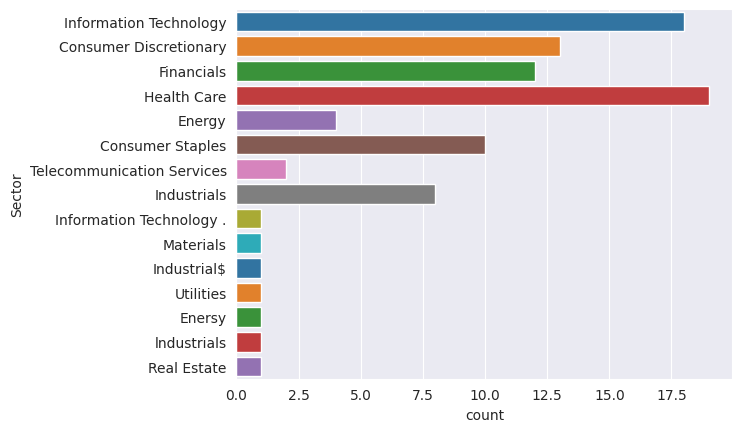

In [15]:
# y='Sector' is the feature from the df to count by.
# data defines the dataframe to be used
# palette='tab10' = each category a different color
# hue='Sector' is required to set the y value to hue when using palette
# legend=False since we don't need a redundant legend
sns.countplot(y='Sector', hue='Sector', legend=False, data=stock_data_v2, palette='tab10')

# Show the plot
plt.show()


![Exercise 3.3](../figures/exercise_3_3.png)

<font color = 'blue'> **EXERCISE 3.3** </font>

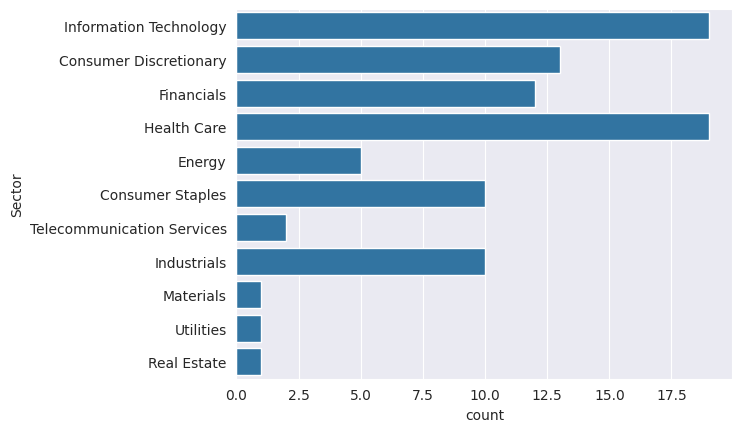

In [22]:
# DATA CLEANING: Fix misspelled and inconsistent sector names

# Replace 'Information Technology .' (note the trailing period and space) with 'Information Technology'
# The nested dictionary structure {'Sector': {'old_value': 'new_value'}} specifies which column and values to replace
# inplace=True modifies the dataframe directly instead of returning a new one
stock_data_v2.replace({'Sector': {'Information Technology .': 'Information Technology'}}, inplace=True)

# Fix the misspelled 'Enersy' to 'Energy'
stock_data_v2.replace({'Sector': {'Enersy': 'Energy'}}, inplace=True)

# Fix multiple variations of 'Industrials' in one operation
# ['Industrial$', 'lndustrials'] is a list of values to all be replaced with 'Industrials'
# Note: 'lndustrials' has a lowercase 'l' instead of an 'I' at the beginning
stock_data_v2.replace({'Sector': {'Industrial$': 'Industrials', 'lndustrials': 'Industrials'}}, inplace=True)

# VISUALIZATION: Create a bar chart showing the count of stocks in each sector

# Parameters:
#   y='Sector': Display sectors on the y-axis
#   data=stock_data_v2: Use the cleaned dataframe as the data source
# This creates a horizontal bar chart with the length of each bar representing the count
sns.countplot(y='Sector', data=stock_data_v2)

# Display the visualization
plt.show()


![Exercise 3.4](../figures/exercise_3_4.png)

<font color = 'blue'> **EXERCISE 3.4** </font>

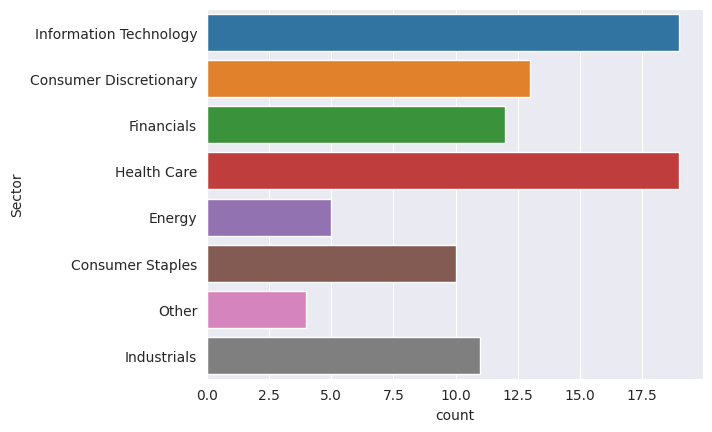

In [27]:
stock_data_v2.replace({'Sector':{'Materials': 'Industrials'}}, inplace=True)
stock_data_v2.replace({'Sector':{'Telecommunication Services': 'Other', 'Utilities':'Other', 'Real Estate': 'Other'}}, inplace=True)

sns.countplot(y='Sector', hue='Sector', palette='tab10', legend=False, data=stock_data_v2)
plt.show()

### 4. Outliers & Unwanted Observations

![Exercise 4.1](../figures/exercise_4_1.png)

<font color = 'blue'> **EXERCISE 4.1** </font>

In [28]:
# Display the dimensions of the stock_data DataFrame
stock_data_v2.shape


(100, 9)

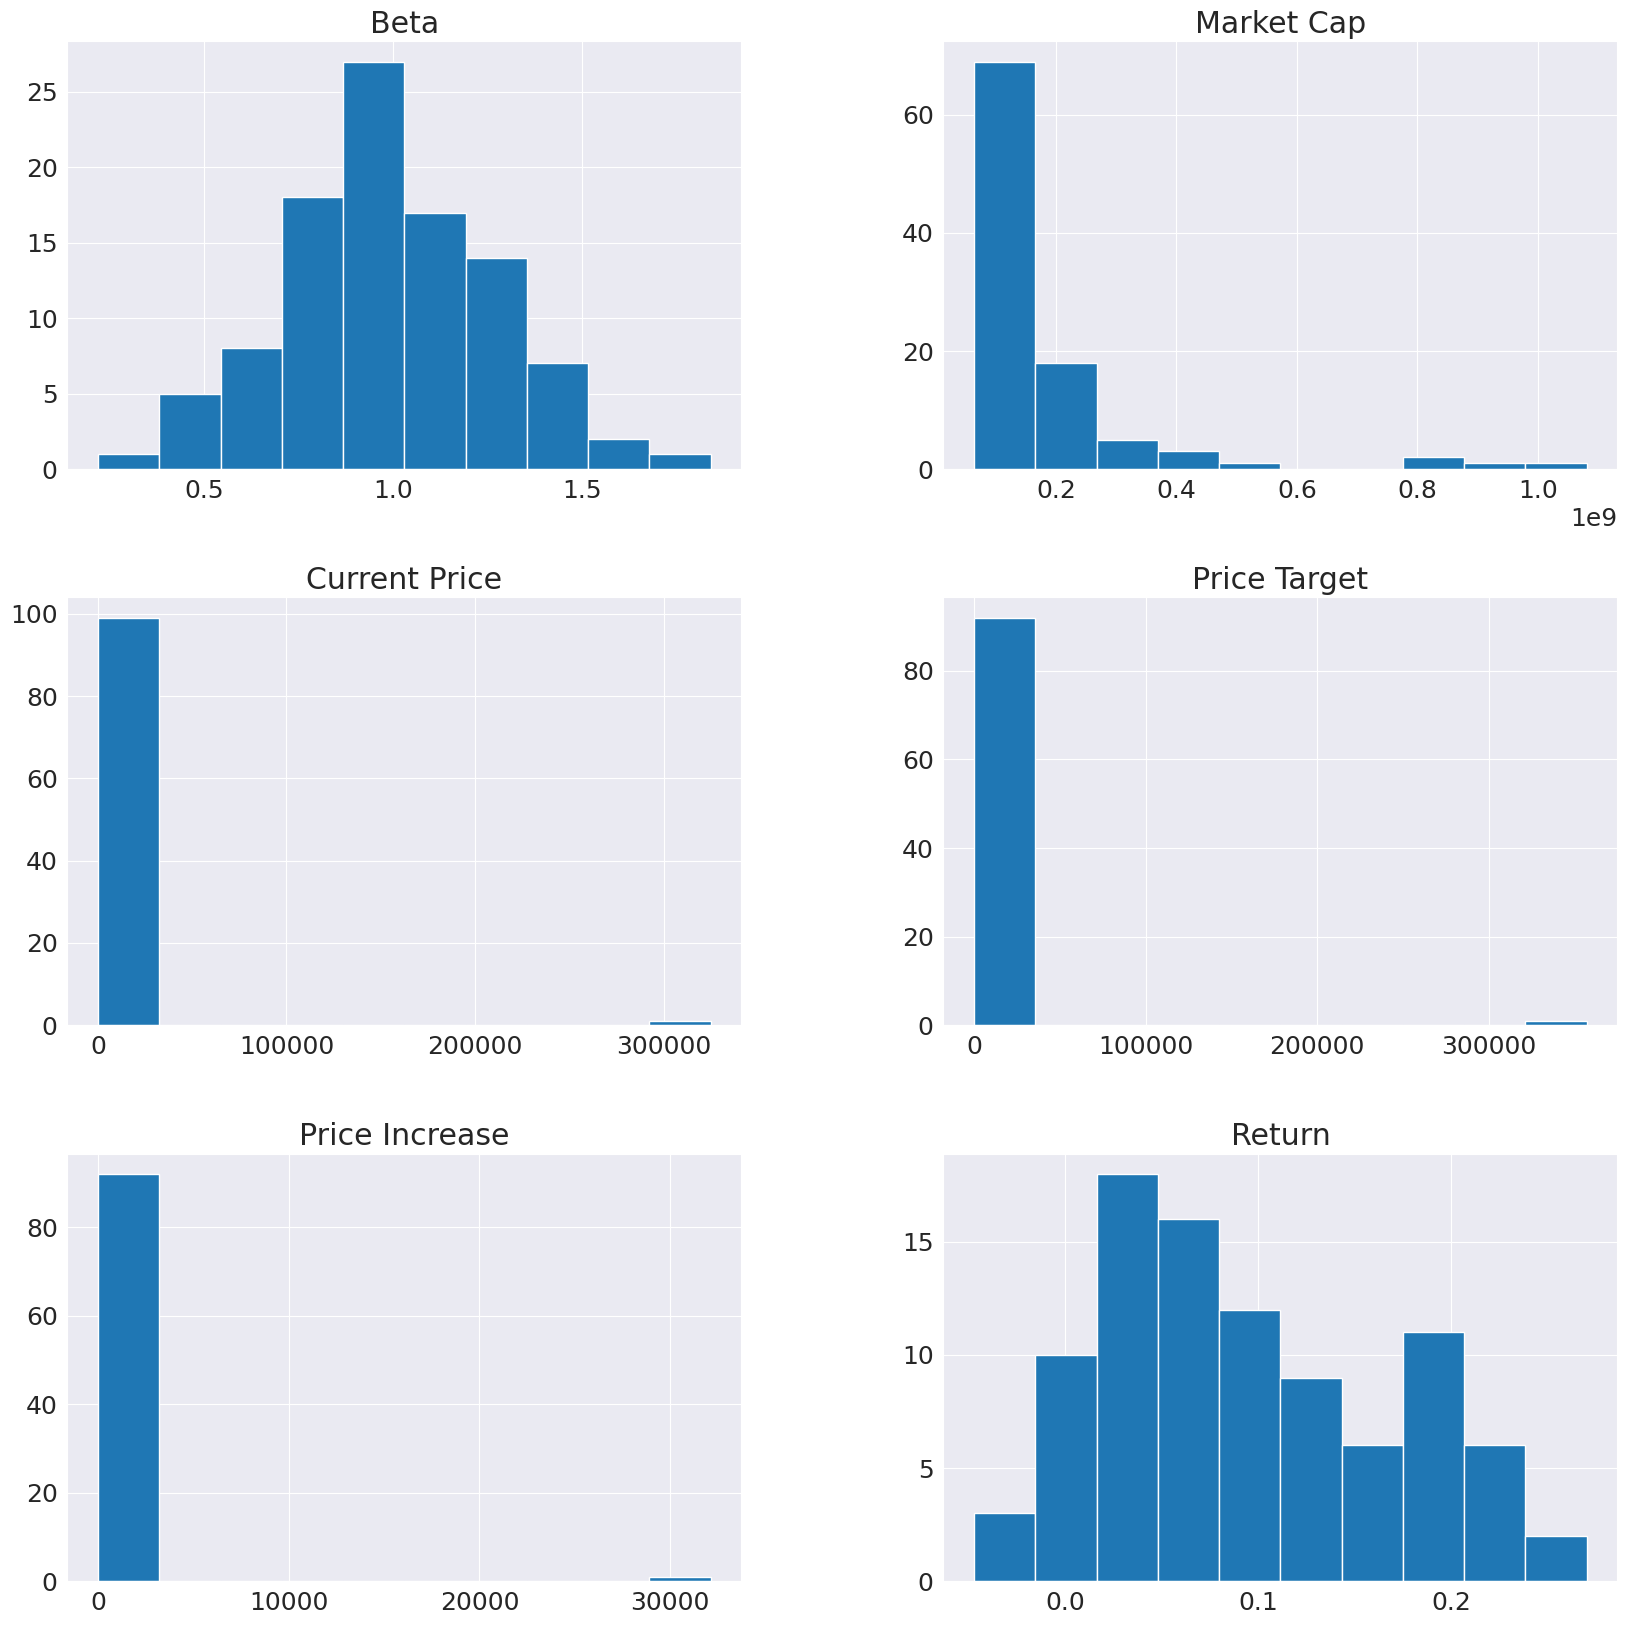

In [32]:
# Display histograms for all continuous features
stock_data_v2.hist(figsize=(20,20))

# Increase the font size
plt.rcParams.update({'font.size': 24})

# Visualize the plots
plt.show()


![Exercise 4.2](../figures/exercise_4_2.png)

<font color = 'blue'> **EXERCISE 4.2** </font>

In [33]:
stock_data_v2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Ticker          100 non-null    object 
 1   Name            100 non-null    object 
 2   Sector          93 non-null     object 
 3   Beta            100 non-null    float64
 4   Market Cap      100 non-null    int64  
 5   Current Price   100 non-null    float64
 6   Price Target    93 non-null     float64
 7   Price Increase  93 non-null     float64
 8   Return          93 non-null     float64
dtypes: float64(5), int64(1), object(3)
memory usage: 7.2+ KB


In [34]:
mask = stock_data_v2['Current Price']>200000
df_high = stock_data_v2[mask]
print(df_high)

  Ticker              Name      Sector  Beta  Market Cap  Current Price  \
4  BRK/A  BERKSHIRE HATH-A  Financials  1.13   534247506       324999.0   

   Price Target  Price Increase  Return  
4      357125.0         32126.0   0.099  


![Exercise 4.3a](../figures/exercise_4_3a.png)

<font color = 'blue'> **EXERCISE 4.3a** </font>

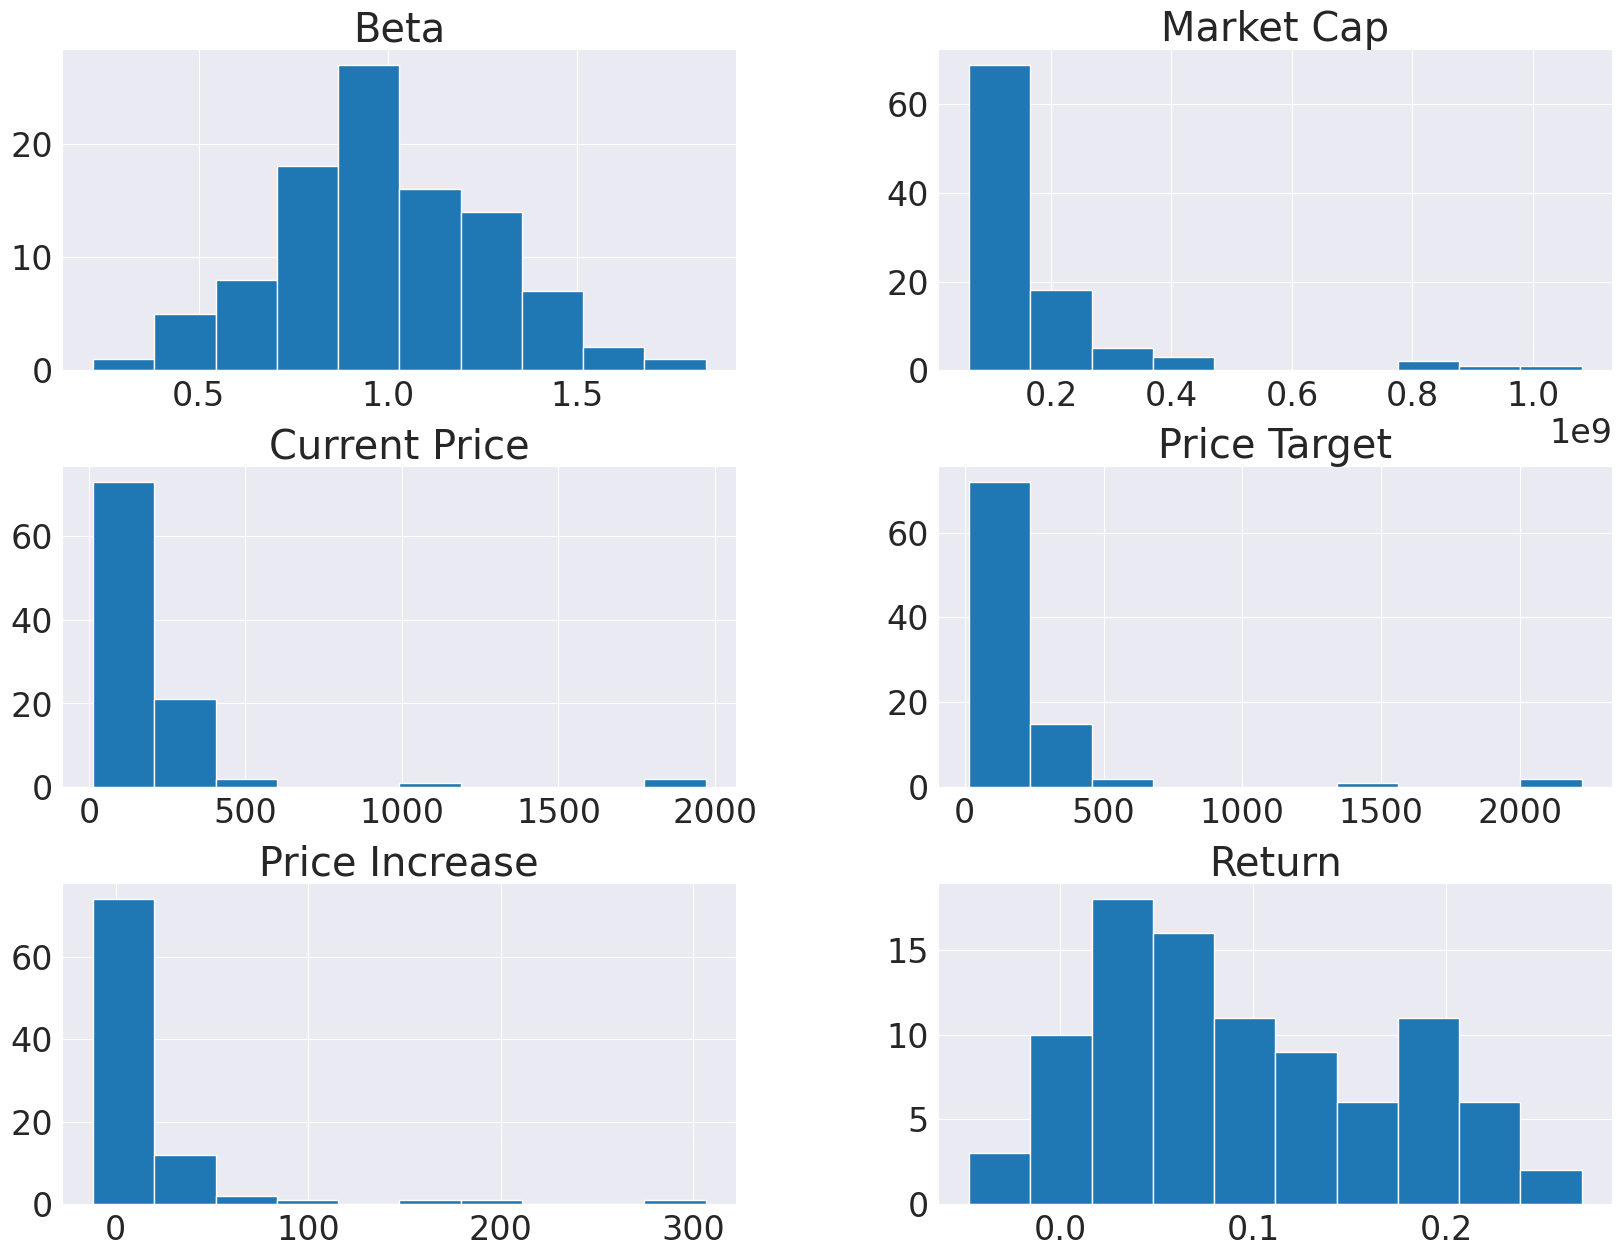

In [35]:
stock_data_mask_out = stock_data_v2[stock_data_v2['Current Price']<300000]
stock_data_mask_out.hist(figsize=(20,15))
plt.show()

![Exercise 4.3b](../figures/exercise_4_3b.png)

<font color = 'blue'> **EXERCISE 4.3b** </font>

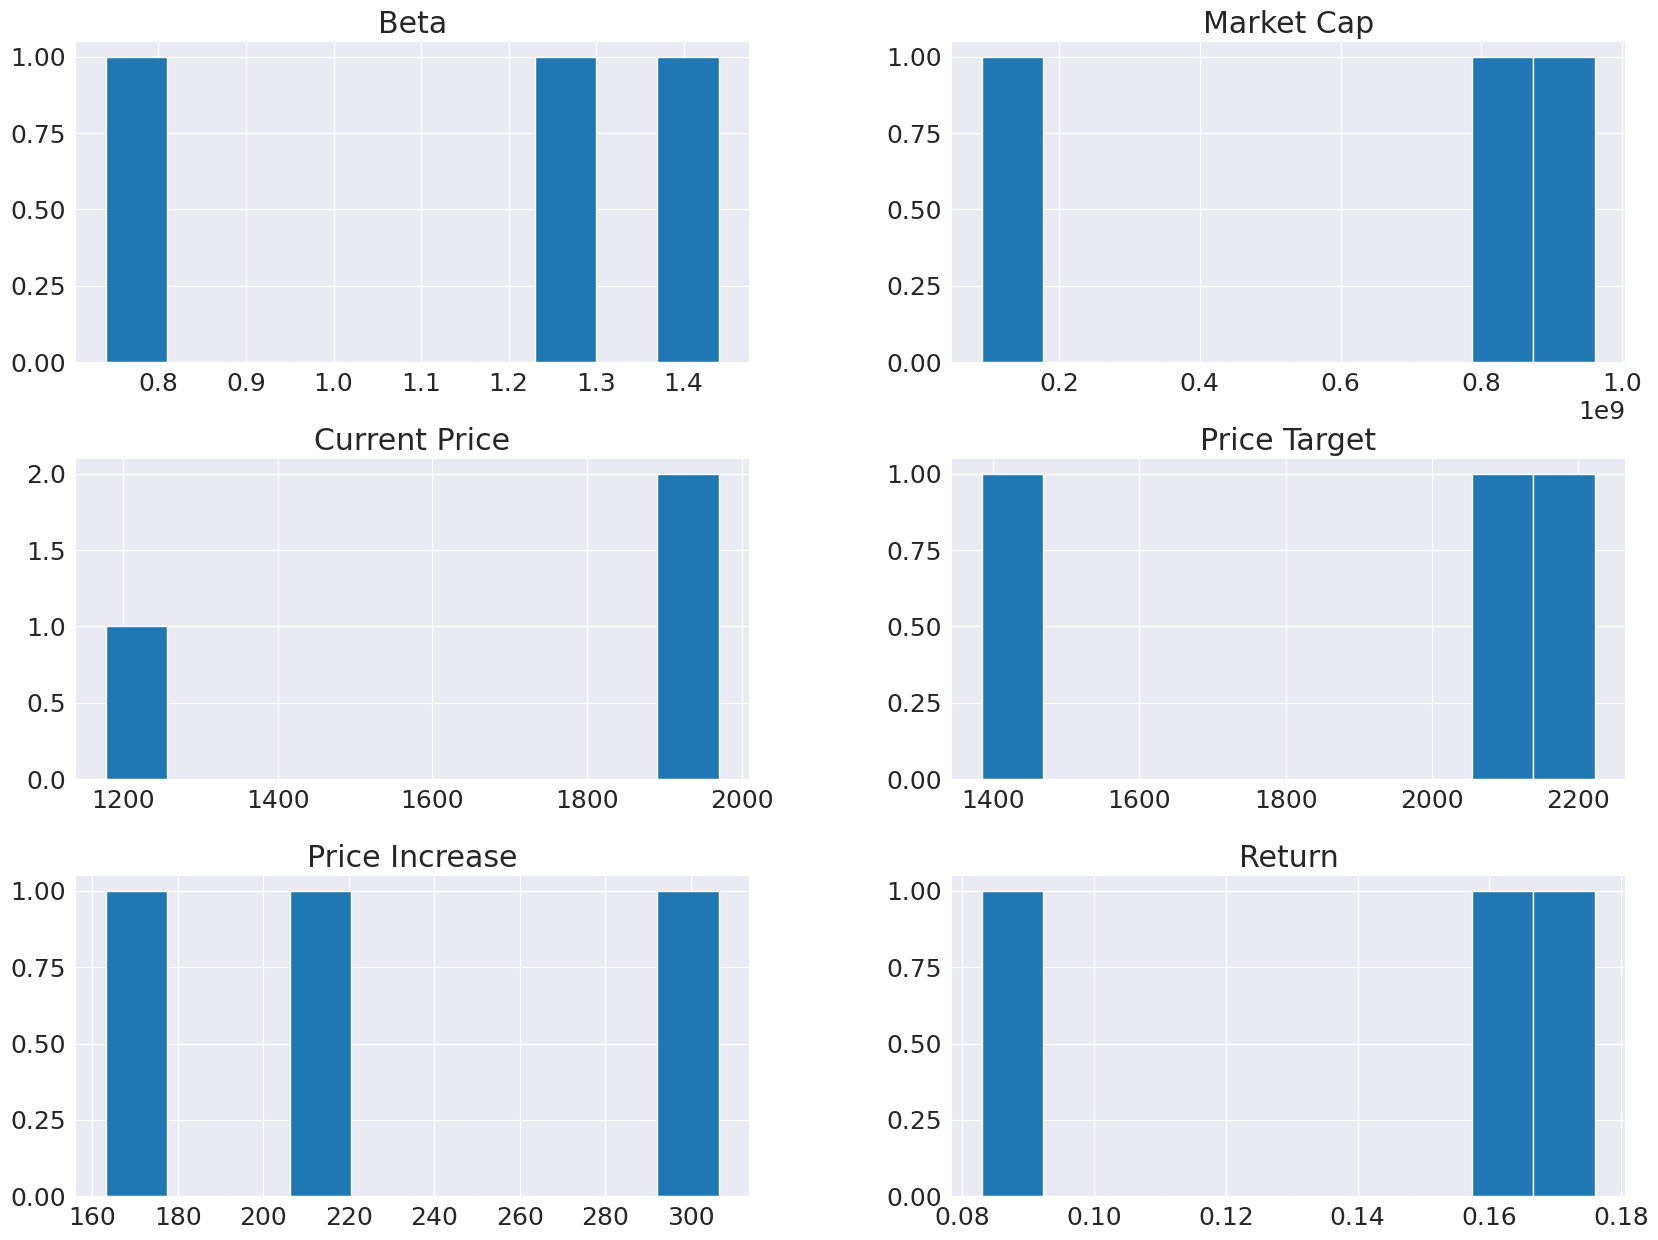

In [42]:
# All stock data with current price above $1K
stock_data_mask_out_above_1K = stock_data_mask_out[stock_data_mask_out['Current Price']>1000]
stock_data_mask_out_above_1K.hist(figsize=(20,15))

# Decrease the font size
plt.rcParams.update({'font.size': 20})

# Display the plot
plt.show()

In [43]:
stock_data_mask_out_above_1K[['Ticker', 'Name', 'Market Cap', 'Current Price']]
# stock_data_mask_out_above_1K.info()


,Ticker,Name,Market Cap,Current Price
1,AMZN,AMAZON.COM INC,960942834,1970.19
3,GOOGL,ALPHABET INC-A,817459888,1177.98
66,BKNG,BOOKING HOLDINGS,90969219,1916.27


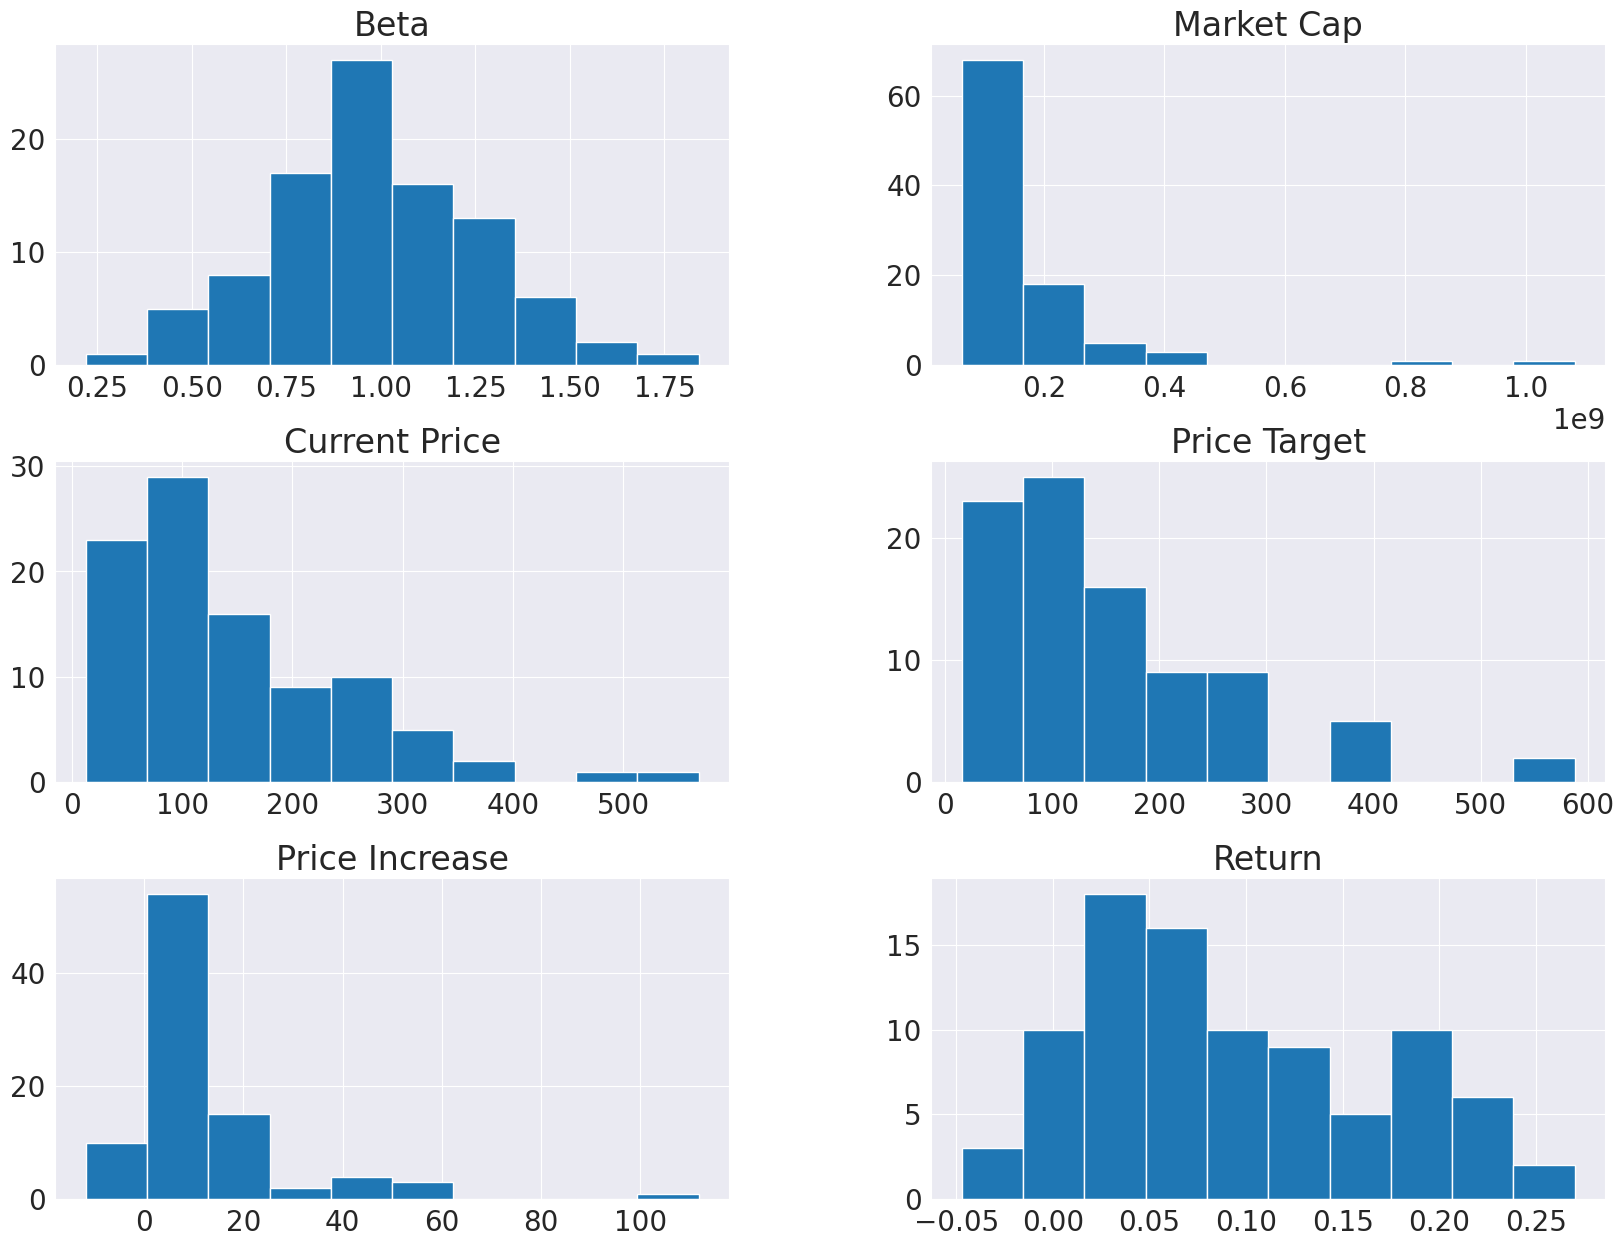

In [44]:
# All stock data with current price below $1K
stock_data_mask_out_below_1K = stock_data_mask_out[stock_data_mask_out['Current Price']<1000]
stock_data_mask_out_below_1K.hist(figsize=(20, 15))
plt.show()

![Exercise 4.4](../figures/exercise_4_4.png)

<font color = 'blue'> **EXERCISE 4.4** </font>

In [45]:
# summary statistics of all stock
stock_data_v2.describe()

,Beta,Market Cap,Current Price,Price Target,Price Increase,Return
count,100.000000,1.000000e+02,100.000000,93.000000,93.000000,93.000000
mean,0.995800,1.756136e+08,3441.165500,4051.011720,364.757312,0.093785
std,0.283446,1.806083e+08,32481.881894,37011.566893,3329.559536,0.073745
min,0.220000,6.389023e+07,12.680000,15.560000,-11.770000,-0.047000
25%,0.810000,8.195384e+07,69.630000,74.530000,3.880000,0.035000
50%,0.990000,1.119556e+08,117.600000,123.930000,8.930000,0.079000
75%,1.182500,1.987309e+08,219.430000,217.130000,16.560000,0.149000
max,1.840000,1.081131e+09,324999.000000,357125.000000,32126.000000,0.270000


In [46]:
# summary statistics of stock below $1K
stock_data_mask_out_below_1K.describe()


,Beta,Market Cap,Current Price,Price Target,Price Increase,Return
count,96.000000,9.600000e+01,96.000000,89.000000,89.000000,89.00000
mean,0.990000,1.578931e+08,146.386562,155.932921,12.582135,0.09218
std,0.283122,1.463478e+08,102.901329,112.550556,16.865557,0.07453
min,0.220000,6.389023e+07,12.680000,15.560000,-11.770000,-0.04700
25%,0.810000,8.099544e+07,68.540000,71.570000,3.740000,0.03400
50%,0.985000,1.102842e+08,114.230000,122.150000,8.650000,0.07800
75%,1.157500,1.884832e+08,204.032500,205.930000,14.250000,0.14700
max,1.840000,1.081131e+09,568.360000,587.790000,111.730000,0.27000


## Note the count in the column are missing data points in some of the columns.  This should be investigated prior to running the ML algorithm

![Exercise 4.5](../figures/exercise_4_5.png)

<font color = 'blue'> **EXERCISE 4.5** </font>

In [17]:
stock_data_mask_null_price_target = stock_data_mask_out_below_1K[pd.isnull(stock_data_mask_out_below_1K['Price Target'])]
print(stock_data_mask_null_price_target)

   Ticker              Name Sector  Beta  Market Cap  Current Price  \
12    SPY  SPDR S&P 500 ETF    NaN  1.00   270949532         290.88   
31     IW  ISHARES-C S&P500    NaN  1.01   164820451         292.91   
54    VTI  VANGUARD TL SK E    NaN  0.98   106340549         150.28   
55    VOO  VANGUARD S&P 500    NaN  0.99   104131469         267.36   
81    QQQ  INVESCO QQQ TRUS    NaN  1.22    71443317         183.99   
83    EFA  ISHARES MSCI EAF    NaN  0.76    69817606          66.76   
84    VEA  VANGUARD FTSE ET    NaN  0.76    69795021          42.71   

    Price Target  Price Increase  Return  
12           NaN             NaN     NaN  
31           NaN             NaN     NaN  
54           NaN             NaN     NaN  
55           NaN             NaN     NaN  
81           NaN             NaN     NaN  
83           NaN             NaN     NaN  
84           NaN             NaN     NaN  


![Exercise 4.6](../figures/exercise_4_6.png)

<font color = 'blue'> **EXERCISE 4.6** </font>

In [18]:
stock_data_v2 = stock_data_v2.dropna()
stock_data_v2.describe()

,Beta,Market Cap,Current Price,Price Target,Price Increase,Return
count,93.000000,9.300000e+01,93.000000,93.000000,93.000000,93.000000
mean,0.998495,1.796136e+08,3686.254409,4051.011720,364.757312,0.093785
std,0.291010,1.857849e+08,33682.068837,37011.566893,3329.559536,0.073745
min,0.220000,6.389023e+07,12.680000,15.560000,-11.770000,-0.047000
25%,0.810000,8.270243e+07,69.980000,74.530000,3.880000,0.035000
50%,0.990000,1.164038e+08,114.570000,123.930000,8.930000,0.079000
75%,1.190000,2.067081e+08,209.070000,217.130000,16.560000,0.149000
max,1.840000,1.081131e+09,324999.000000,357125.000000,32126.000000,0.270000


In [19]:
# drop na for stock prices below $1K
stock_data_mask_out_below_1K = stock_data_mask_out_below_1K.dropna()
stock_data_mask_out_below_1K.describe()

,Beta,Market Cap,Current Price,Price Target,Price Increase,Return
count,89.000000,8.900000e+01,89.000000,89.000000,89.000000,89.00000
mean,0.992360,1.606791e+08,143.350787,155.932921,12.582135,0.09218
std,0.291064,1.504772e+08,102.779789,112.550556,16.865557,0.07453
min,0.220000,6.389023e+07,12.680000,15.560000,-11.770000,-0.04700
25%,0.810000,8.197373e+07,68.580000,71.570000,3.740000,0.03400
50%,0.980000,1.135957e+08,113.500000,122.150000,8.650000,0.07800
75%,1.180000,1.955919e+08,200.580000,205.930000,14.250000,0.14700
max,1.840000,1.081131e+09,568.360000,587.790000,111.730000,0.27000


![Exercise 4.7](../figures/exercise_4_7.png)

<font color = 'blue'> **EXERCISE 4.7** </font>

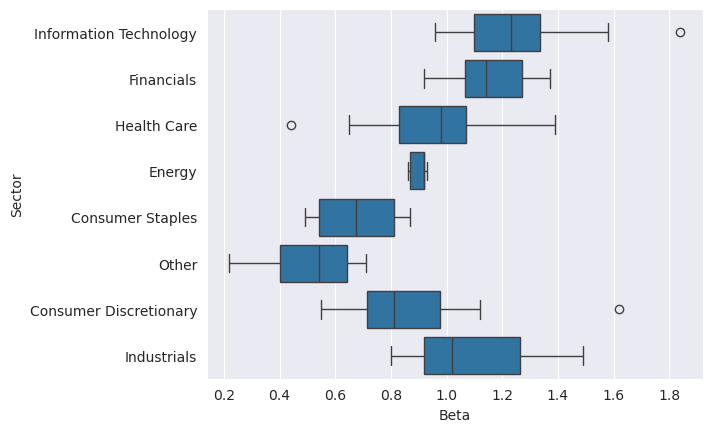

In [22]:
# Display the box distribution of 'Beta' by 'Sector'
sns.boxplot(y='Sector', x='Beta', data=stock_data_mask_out_below_1K)
plt.show()


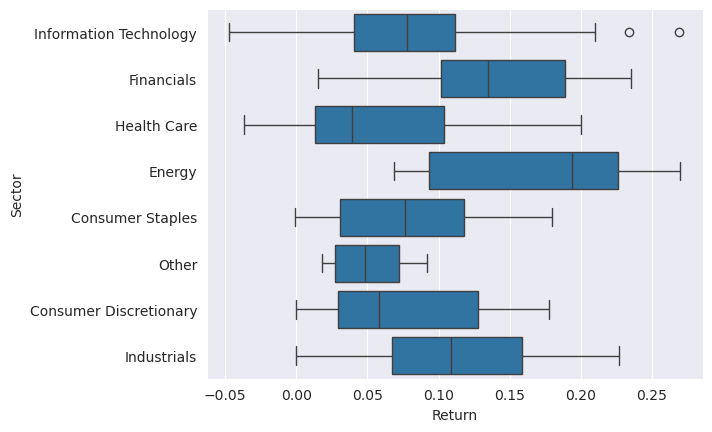

In [23]:
# Display the box distribution of 'Return' by 'Sector'
sns.boxplot(y='Sector', x='Return', data=stock_data_mask_out_below_1K)
plt.show()


## Saving the cleaned dataframe

In [28]:
stock_data_mask_out_below_1K.to_csv('./processed_notebooks/stock_data_v3.csv', index=None)

In [29]:
# Check if the directory exists
print(f"Directory exists: {os.path.exists('./processed_notebooks')}")

# Get the absolute path of the current working directory
print(f"Current working directory: {os.getcwd()}")

# Try to list files in the processed_notebooks directory if it exists
if os.path.exists('./processed_notebooks'):
    print("\nFiles in processed_notebooks directory:")
    print(os.listdir('./processed_notebooks'))
else:
    print("\nThe processed_notebooks directory does not exist")

Directory exists: True
Current working directory: /home/brice-nelson/Documents/computerScience/Courses/pyfi/machine_learning/module_01/notebooks

Files in processed_notebooks directory:
['stock_data_v3.csv']
